In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
df= pd.read_csv('procurement_requests_5000.csv',parse_dates=['request_date'])

In [4]:
print(f'Всего заявок: {len(df):,}')
print(f'Период: с {df["request_date"].min().date()} по {df["request_date"].max().date()}')
print(f'Количество подразделений: {df["department"].nunique()}')

Всего заявок: 5,000
Период: с 2026-01-01 по 2026-12-31
Количество подразделений: 7


In [5]:
stats = {
    'Средняя сумма заявки': f"{df['amount'].mean():,.2f} ₽",
    'Медианная сумма': f"{df['amount'].median():,.2f} ₽",
    'Среднее время обработки': f"{df['total_time_hours'].mean():.1f} ч",
    'Медианное время обработки': f"{df['total_time_hours'].median():.1f} ч",
    'Среднее количество возвратов': f"{df['return_count'].mean():.2f}",
    'Среднее количество уточнений': f"{df['clarification_count'].mean():.2f}",
    'Доля одобренных': f"{df[df['final_status'] == 'Одобрена'].shape[0] / len(df) * 100:.1f}%",
    'Доля отклонённых': f"{df[df['final_status'] == 'Отклонена'].shape[0] / len(df) * 100:.1f}%",
    'Доля в процессе': f"{df[df['final_status'] == 'В процессе'].shape[0] / len(df) * 100:.1f}%"
}
for key, value in stats.items():
    print(f'{key:35} {value}')

Средняя сумма заявки                127,224.23 ₽
Медианная сумма                     42,525.35 ₽
Среднее время обработки             25.8 ч
Медианное время обработки           16.9 ч
Среднее количество возвратов        0.18
Среднее количество уточнений        0.63
Доля одобренных                     84.8%
Доля отклонённых                    7.5%
Доля в процессе                     7.7%


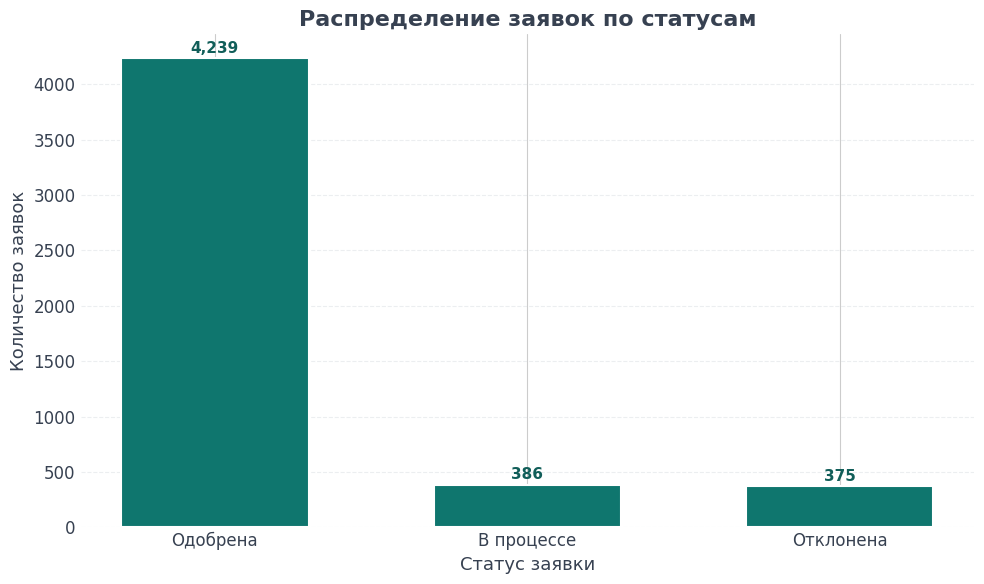

In [26]:
plt.figure(figsize=(10, 6))

status_counts = df['final_status'].value_counts()

bars = plt.bar(
    status_counts.index,
    status_counts.values,
    color='#0F766E',
    edgecolor='white',
    linewidth=1.5,
    width=0.6
)

plt.title(
    'Распределение заявок по статусам',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Статус заявки')
plt.ylabel('Количество заявок')

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4,
    color='#D1D5DB'
)

for bar, count in zip(bars, status_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{count:,}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='#115E59'
    )

plt.tight_layout()
plt.show()

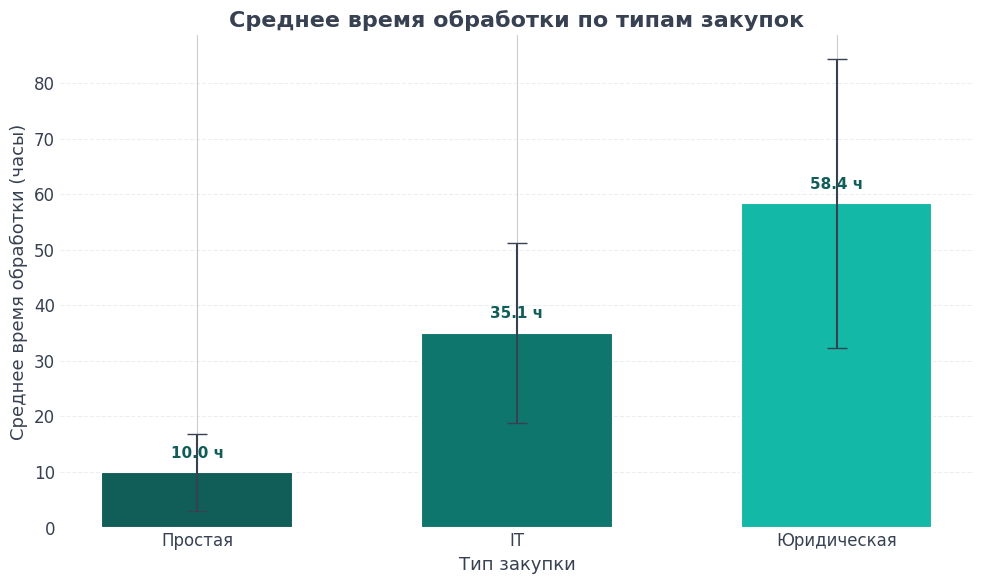

In [27]:
plt.figure(figsize=(10, 6))

stats = (
    df.groupby('purchase_type')['total_time_hours']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

order = [
    'Простая',
    'IT',
    'Юридическая'
]

stats['purchase_type'] = pd.Categorical(
    stats['purchase_type'],
    categories=order,
    ordered=True
)

stats = stats.sort_values('purchase_type')

bars = plt.bar(
    stats['purchase_type'],
    stats['mean'],
    yerr=stats['std'],
    capsize=7,
    color=[
        '#115E59',
        '#0F766E',
        '#14B8A6'
    ],
    edgecolor='white',
    linewidth=1.5,
    width=0.6,
    error_kw={
        'linewidth': 1.5,
        'ecolor': '#374151'
    }
)

plt.title(
    'Среднее время обработки по типам закупок',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Тип закупки')
plt.ylabel('Среднее время обработки (часы)')

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4,
    color='#D1D5DB'
)

for bar, mean_val in zip(
    bars,
    stats['mean']
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f'{mean_val:.1f} ч',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='#115E59'
    )

plt.tight_layout()
plt.show()

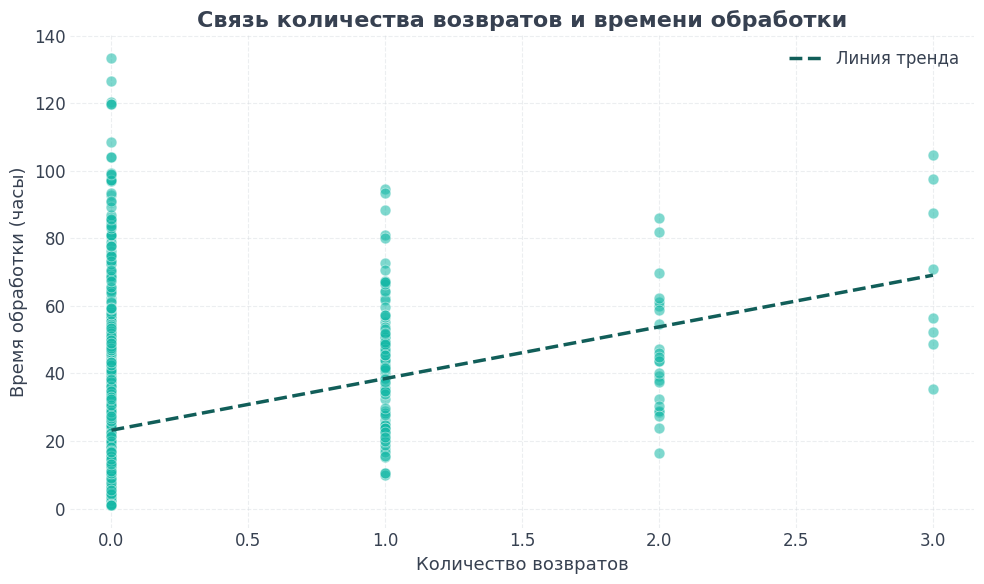

In [28]:

plt.figure(figsize=(10, 6))

df_sample = df.sample(
    n=min(1000, len(df)),
    random_state=42
)

plt.scatter(
    df_sample['return_count'],
    df_sample['total_time_hours'],
    color='#14B8A6',
    alpha=0.55,
    s=60,
    edgecolors='white',
    linewidth=0.5
)

plt.title(
    'Связь количества возвратов и времени обработки',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Количество возвратов')
plt.ylabel('Время обработки (часы)')

plt.grid(
    linestyle='--',
    alpha=0.4,
    color='#D1D5DB'
)

if df_sample['return_count'].nunique() > 1:

    z = np.polyfit(
        df_sample['return_count'],
        df_sample['total_time_hours'],
        1
    )

    p = np.poly1d(z)

    x_trend = np.linspace(
        df_sample['return_count'].min(),
        df_sample['return_count'].max(),
        100
    )

    plt.plot(
        x_trend,
        p(x_trend),
        '--',
        color='#115E59',
        linewidth=2.5,
        label='Линия тренда'
    )

    plt.legend()

plt.tight_layout()
plt.show()

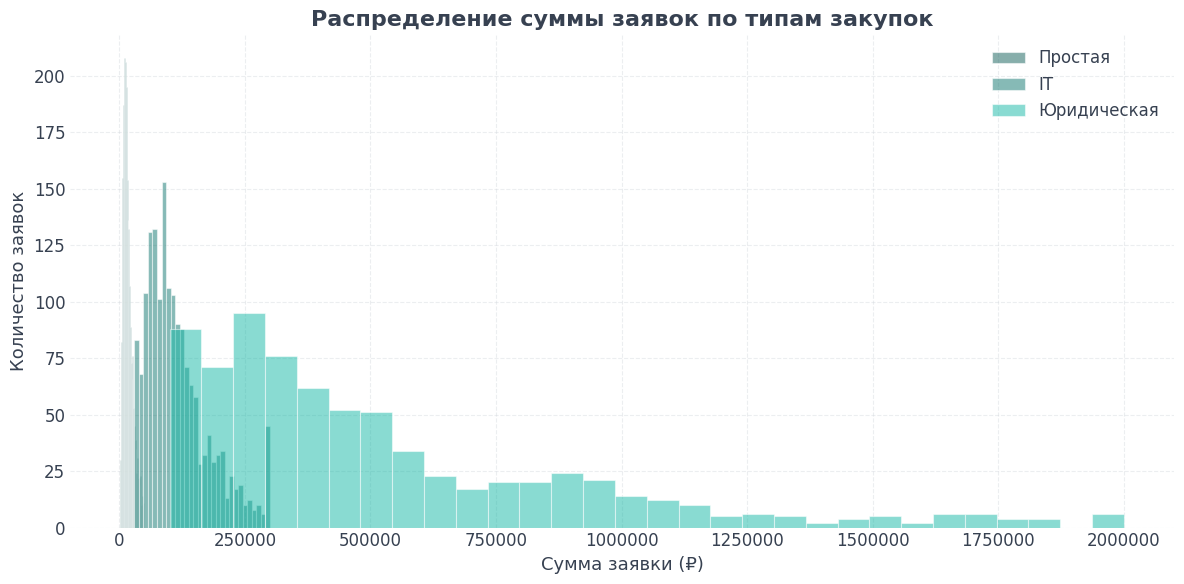

In [29]:
plt.figure(figsize=(12, 6))

order = [
    'Простая',
    'IT',
    'Юридическая'
]

colors = [
    '#115E59',
    '#0F766E',
    '#14B8A6'
]

for i, purchase_type in enumerate(order):

    subset = df[
        df['purchase_type'] == purchase_type
    ]['amount']

    plt.hist(
        subset,
        bins=30,
        alpha=0.5,
        color=colors[i],
        label=purchase_type,
        edgecolor='white',
        linewidth=0.8
    )

plt.title(
    'Распределение суммы заявок по типам закупок',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Сумма заявки (₽)')
plt.ylabel('Количество заявок')

plt.ticklabel_format(
    style='plain',
    axis='x'
)

plt.grid(
    linestyle='--',
    alpha=0.4,
    color='#D1D5DB'
)

plt.legend()

plt.tight_layout()
plt.show()

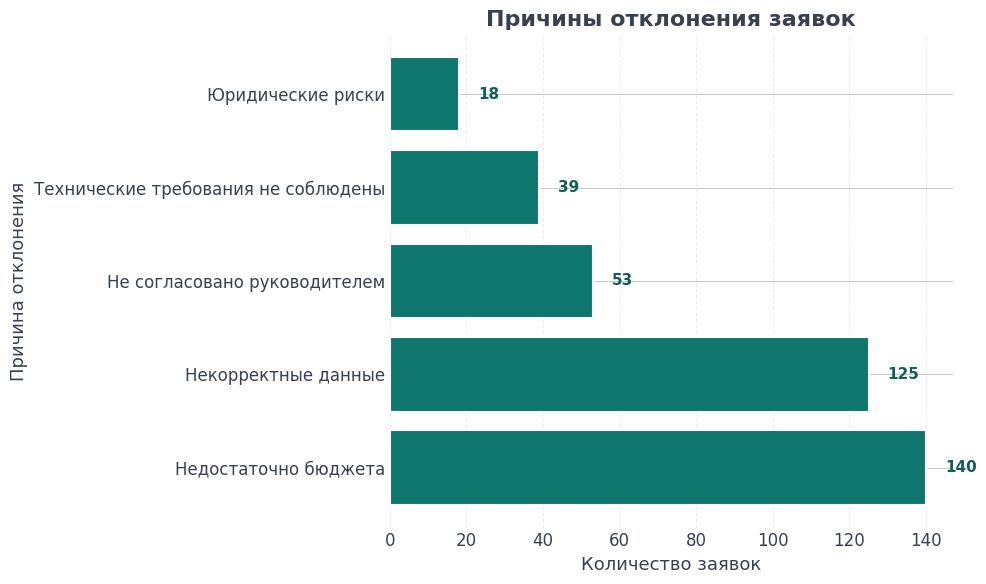

In [30]:
plt.figure(figsize=(10, 6))

rejected_df = df[
    df['final_status'] == 'Отклонена'
]

if (
    len(rejected_df) > 0
    and rejected_df['rejection_reason'].notna().any()
):

    reason_counts = (
        rejected_df['rejection_reason']
        .value_counts()
    )

    bars = plt.barh(
        reason_counts.index,
        reason_counts.values,
        color='#0F766E',
        edgecolor='white',
        linewidth=1.5
    )

    plt.title(
        'Причины отклонения заявок',
        fontsize=16,
        fontweight='bold'
    )

    plt.xlabel('Количество заявок')
    plt.ylabel('Причина отклонения')

    plt.grid(
        axis='x',
        linestyle='--',
        alpha=0.4,
        color='#D1D5DB'
    )

    for bar, count in zip(
        bars,
        reason_counts.values
    ):
        plt.text(
            bar.get_width() + 5,
            bar.get_y() + bar.get_height() / 2,
            f'{count:,}',
            va='center',
            fontsize=11,
            fontweight='bold',
            color='#115E59'
        )

else:

    plt.text(
        0.5,
        0.5,
        'Нет данных об отклонениях',
        ha='center',
        va='center',
        fontsize=16,
        color='#374151'
    )

    plt.title(
        'Причины отклонения заявок',
        fontsize=16,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


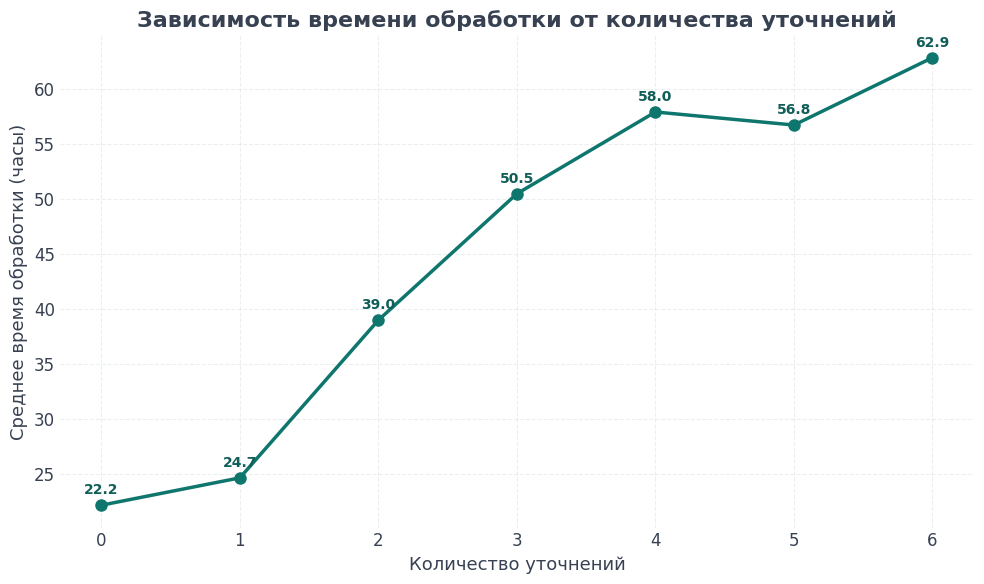

In [31]:
plt.figure(figsize=(10, 6))

clarification_stats = (
    df.groupby('clarification_count')['total_time_hours']
    .mean()
    .reset_index()
)

plt.plot(
    clarification_stats['clarification_count'],
    clarification_stats['total_time_hours'],
    marker='o',
    linewidth=2.5,
    markersize=8,
    color='#0F766E'
)

plt.title(
    'Зависимость времени обработки от количества уточнений',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Количество уточнений')
plt.ylabel('Среднее время обработки (часы)')

plt.grid(
    linestyle='--',
    alpha=0.4,
    color='#D1D5DB'
)

for x, y in zip(
    clarification_stats['clarification_count'],
    clarification_stats['total_time_hours']
):
    plt.text(
        x,
        y + 1,
        f'{y:.1f}',
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='#115E59'
    )

plt.tight_layout()
plt.show()

Основные выводы:
1. Средняя сумма значительно выше медианной.
Средняя сумма заявки составляет 127,2 тыс., тогда как медианная 42,5 тыс. Это указывает на наличие относительно небольшого количества заявок с существенно большей суммой, которые заметно влияют на среднее значение.
2. Распределение времени обработки также неравномерное.
Среднее время обработки составляет 25,8 часа, а медианное -16,9 часа.
3. Большинство заявок успешно проходит процесс.
84,8% заявок имеют статус «Одобрена», тогда как 7,5% отклонены. При этом 7,7% находятся в процессе обработки.
4. Возвраты и уточнения встречаются относительно редко в среднем, однако увеличение их количества связано с ростом общего времени обработки. Это делает возвраты потенциальной точкой оптимизации процесса.